In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set plot style
sns.set(style="whitegrid")

In [17]:
# 1. Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. Robust Data Cleaning Function
def clean_data(df):
    df = df.copy()
    
    # Replace '?' with NaN globally
    df.replace('?', np.nan, inplace=True)
    
    # Drop ID columns that don't add predictive value
    cols_to_drop = ['Customer ID', 'Name', 'Property ID']
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    
    # Force conversion of specific columns to numeric
    # This fixes the "string to float" error for columns that had '?'
    numeric_candidates = [
        'Co-Applicant', 'Property Price', 'Property Age', 
        'Income (USD)', 'Dependents', 'Credit Score',
        'Loan Amount Request (USD)', 'Current Loan Expenses (USD)'
    ]
    for col in numeric_candidates:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    # Feature Engineering: Income (USD) and Property Age are 100% correlated duplicates.
    # We use Property Age to fill missing Income values, then drop Property Age.
    if 'Income (USD)' in df.columns and 'Property Age' in df.columns:
        df['Income (USD)'] = df['Income (USD)'].fillna(df['Property Age'])
        df.drop(columns=['Property Age'], inplace=True)
            
    return df

# Apply cleaning
train_df = clean_data(train_df)
test_df = clean_data(test_df)

# Drop rows in Training set where Target is missing
train_df = train_df.dropna(subset=['Loan Sanction Amount (USD)'])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test Co-Applicant dtype:", test_df['Co-Applicant'].dtype) # Should be float/int now

Train shape: (29660, 20)
Test shape: (20000, 19)
Test Co-Applicant dtype: float64


In [18]:
# Separate Features and Target
X = train_df.drop('Loan Sanction Amount (USD)', axis=1)
y = train_df['Loan Sanction Amount (USD)']
X_test_submit = test_df.copy()

# Identify Numeric and Categorical columns automatically
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print(f"Numeric Columns: {len(numeric_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")

# 1. Impute Missing Values
# Numeric: Fill with Median
imputer_num = SimpleImputer(strategy='median')
X[numeric_cols] = imputer_num.fit_transform(X[numeric_cols])
X_test_submit[numeric_cols] = imputer_num.transform(X_test_submit[numeric_cols])

# Categorical: Fill with Mode (Most Frequent)
imputer_cat = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = imputer_cat.fit_transform(X[categorical_cols])
X_test_submit[categorical_cols] = imputer_cat.transform(X_test_submit[categorical_cols])

# 2. Encode Categorical Variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on combined data to handle all categories
    combined_data = pd.concat([X[col], X_test_submit[col]], axis=0).astype(str)
    le.fit(combined_data)
    
    X[col] = le.transform(X[col].astype(str))
    X_test_submit[col] = le.transform(X_test_submit[col].astype(str))
    label_encoders[col] = le

# 3. Standardize Numerical Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_submit_scaled = scaler.transform(X_test_submit)

# Convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_test_submit_df = pd.DataFrame(X_test_submit_scaled, columns=X.columns)

Numeric Columns: 10
Categorical Columns: 9


C:\Users\raman\AppData\Local\Temp\ipykernel_27812\1277965516.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [19]:
# Split Training Data
X_train, X_val, y_train, y_val = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# Initialize Models
lr = LinearRegression()
ridge = Ridge()
lasso = Lasso(max_iter=5000) # Increased max_iter for convergence with small alphas
enet = ElasticNet(max_iter=5000)

# Cross-Validation Strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- 1. Ridge Tuning ---
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
print(f"Tuning Ridge with params: {ridge_params}")
grid_ridge = GridSearchCV(ridge, ridge_params, cv=kf, scoring='r2')
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_

# --- 2. Lasso Tuning ---
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
print(f"Tuning Lasso with params: {lasso_params}")
grid_lasso = GridSearchCV(lasso, lasso_params, cv=kf, scoring='r2')
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_

# --- 3. Elastic Net Tuning ---
enet_params = {'alpha': [0.01, 0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]}
print(f"Tuning ElasticNet with params: {enet_params}")
grid_enet = GridSearchCV(enet, enet_params, cv=kf, scoring='r2')
grid_enet.fit(X_train, y_train)
best_enet = grid_enet.best_estimator_

# --- 4. Baseline Linear Regression ---
lr.fit(X_train, y_train)

print("\nBest Parameters Found:")
print("Ridge:", grid_ridge.best_params_)
print("Lasso:", grid_lasso.best_params_)
print("ElasticNet:", grid_enet.best_params_)

Tuning Ridge with params: {'alpha': [0.01, 0.1, 1, 10, 100]}
Tuning Lasso with params: {'alpha': [0.001, 0.01, 0.1, 1, 10]}
Tuning ElasticNet with params: {'alpha': [0.01, 0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]}

Best Parameters Found:
Ridge: {'alpha': 100}
Lasso: {'alpha': 10}
ElasticNet: {'alpha': 0.1, 'l1_ratio': 0.8}


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


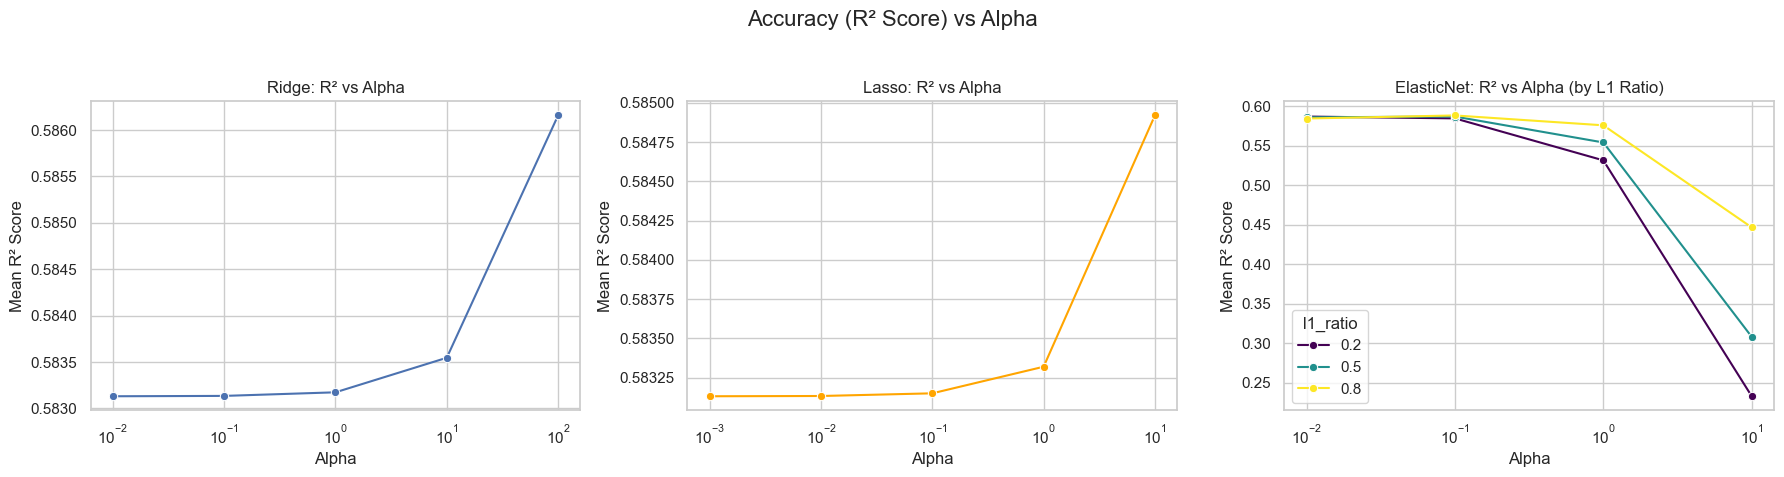

In [24]:
# Extract results for plotting
ridge_results = pd.DataFrame(grid_ridge.cv_results_)
lasso_results = pd.DataFrame(grid_lasso.cv_results_)
enet_results = pd.DataFrame(grid_enet.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Accuracy (R² Score) vs Alpha', fontsize=16)

# 1. Ridge Plot
sns.lineplot(data=ridge_results, x='param_alpha', y='mean_test_score', marker='o', ax=axes[0])
axes[0].set_title('Ridge: R² vs Alpha')
axes[0].set_xscale('log') # Log scale helps visualization across 0.01 to 100
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Mean R² Score')

# 2. Lasso Plot
sns.lineplot(data=lasso_results, x='param_alpha', y='mean_test_score', marker='o', color='orange', ax=axes[1])
axes[1].set_title('Lasso: R² vs Alpha')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Mean R² Score')

# 3. ElasticNet Plot
# Converting param_l1_ratio to float for proper legend grouping
enet_results['l1_ratio'] = enet_results['param_l1_ratio'].astype(float)
sns.lineplot(data=enet_results, x='param_alpha', y='mean_test_score', hue='l1_ratio', marker='o', palette='viridis', ax=axes[2])
axes[2].set_title('ElasticNet: R² vs Alpha (by L1 Ratio)')
axes[2].set_xscale('log')
axes[2].set_xlabel('Alpha')
axes[2].set_ylabel('Mean R² Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('R2_vs_alpha.eps', format='eps')
plt.show()

In [28]:
models = {
    'Linear Regression': lr,
    'Ridge': best_ridge,
    'Lasso': best_lasso,
    'ElasticNet': best_enet
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_val)
    # Sanity check: Loans cannot be negative
    y_pred = np.maximum(y_pred, 0)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    results.append({'Model': name, 'MSE':mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

results_df = pd.DataFrame(results)
print(results_df)

               Model           MSE          RMSE           MAE        R2
0  Linear Regression  1.014823e+09  31856.283721  21333.582496  0.552897
1              Ridge  1.013890e+09  31841.639438  21358.281004  0.553308
2              Lasso  1.014657e+09  31853.685959  21334.870436  0.552970
3         ElasticNet  1.013467e+09  31834.994374  21445.180152  0.553494


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


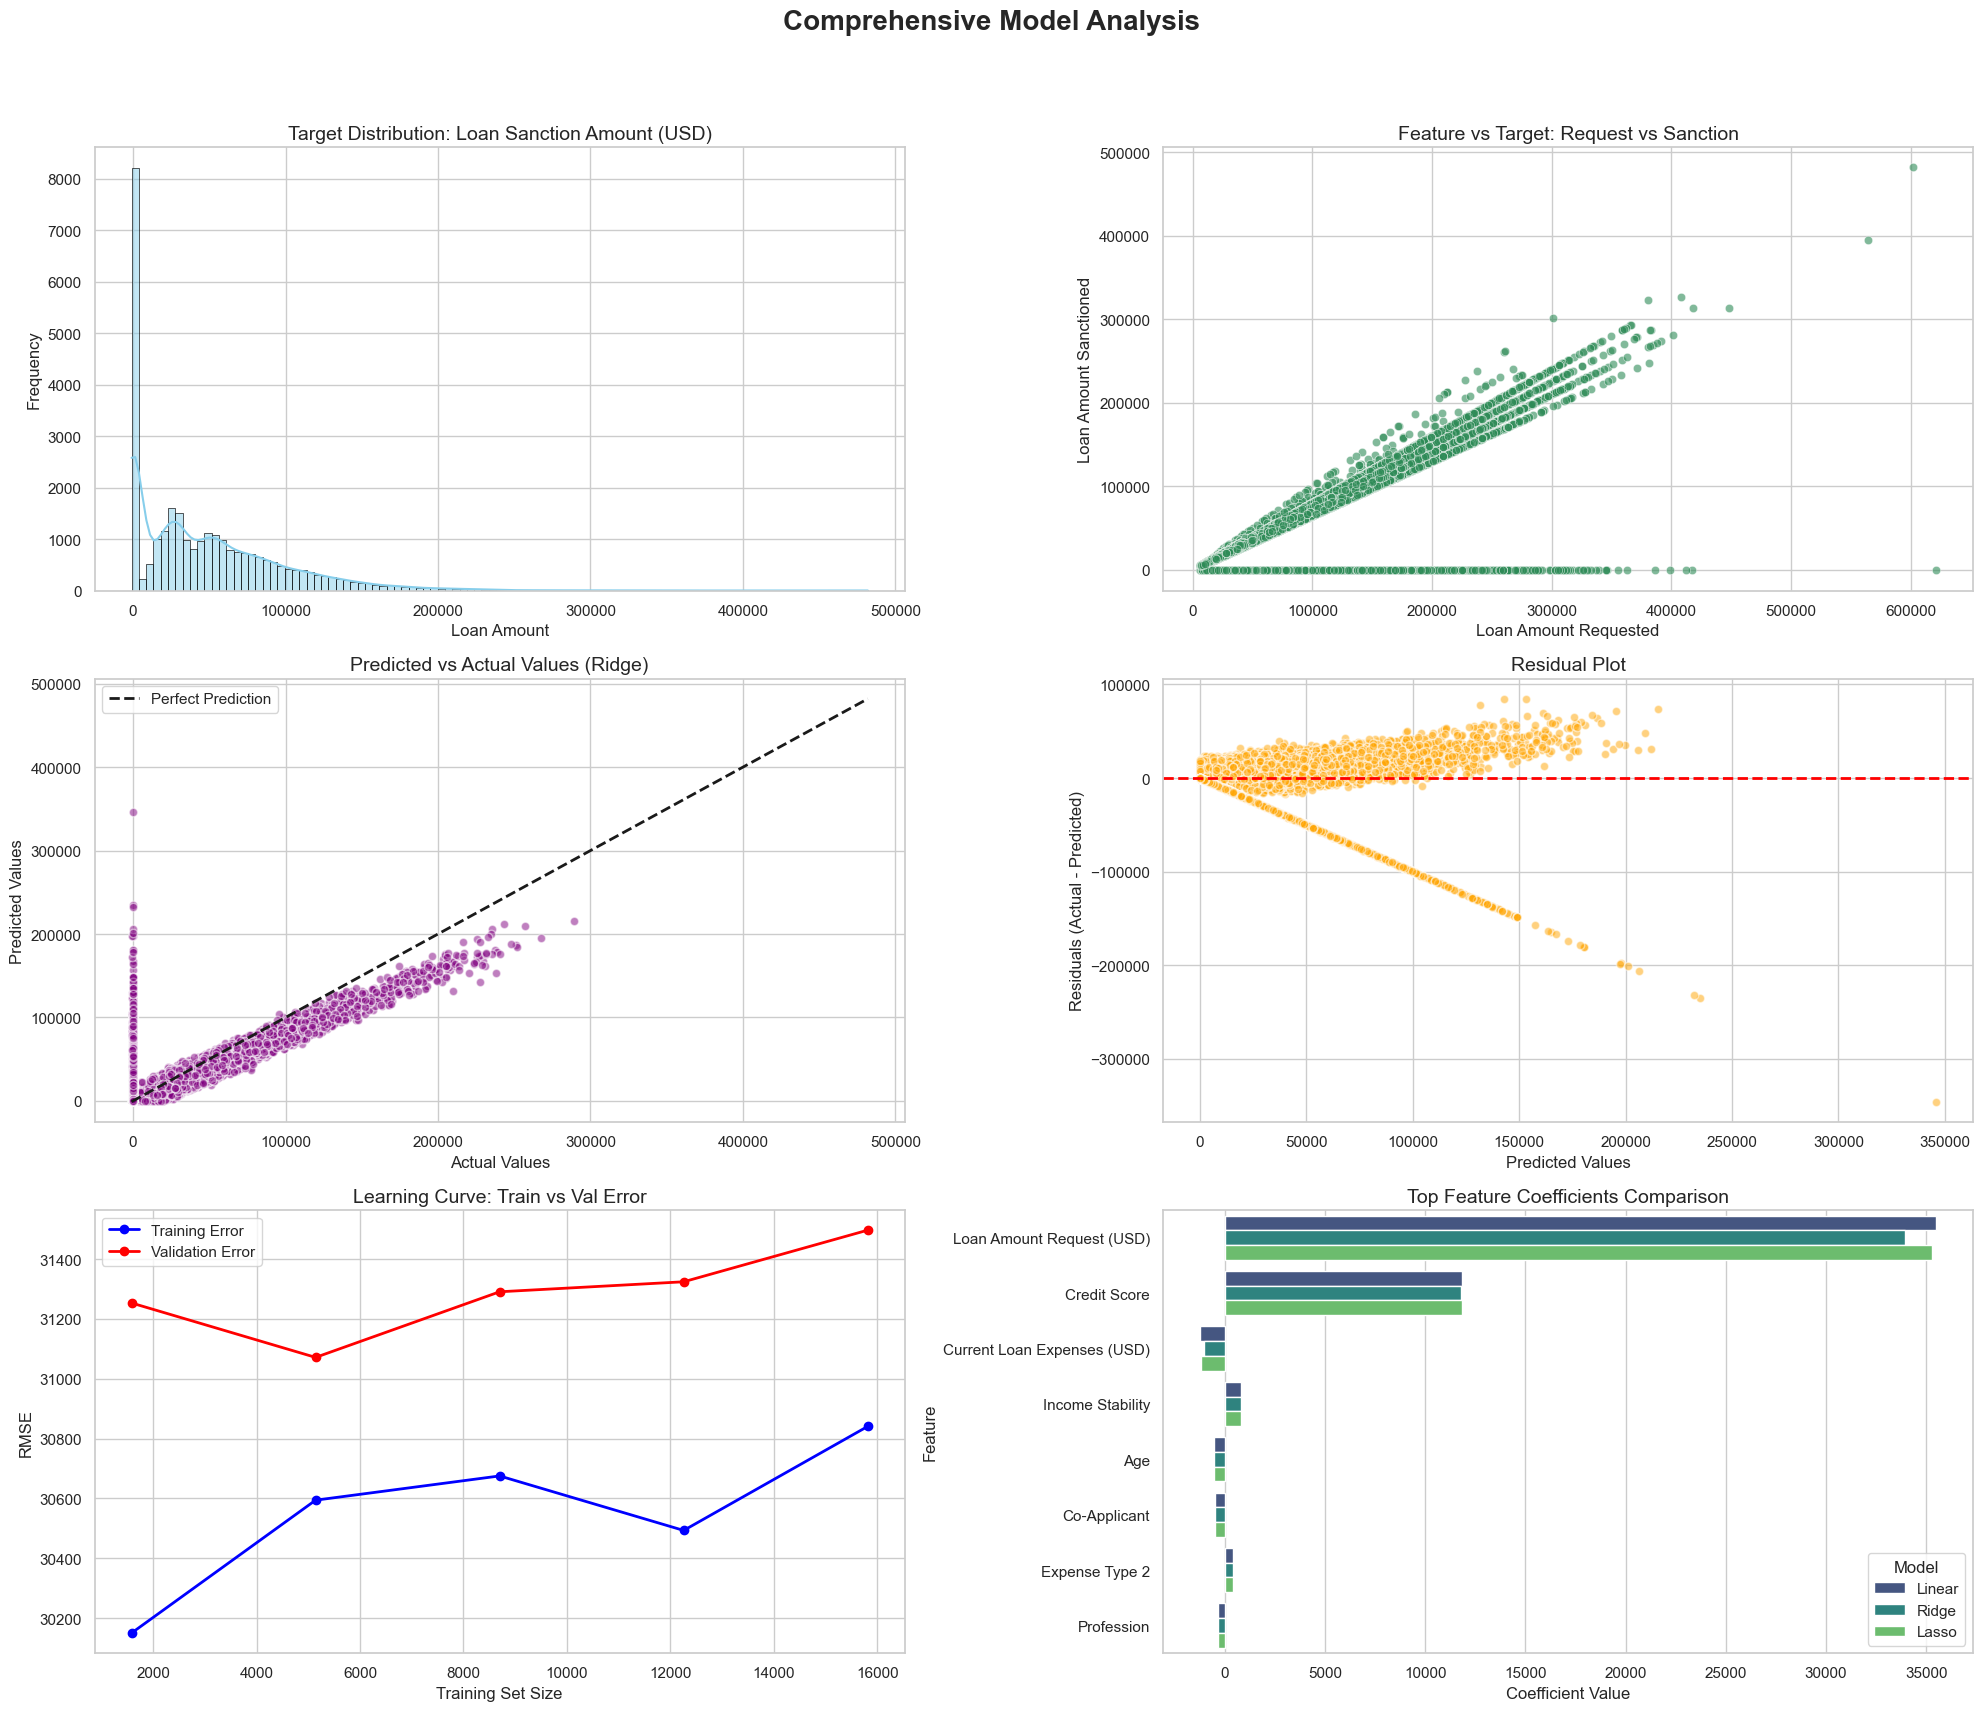

In [27]:
# Create a figure with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Comprehensive Model Analysis', fontsize=20, weight='bold')

# --- 1. Target Variable Distribution ---
# Shows how the Loan Sanction Amounts are distributed
sns.histplot(y, kde=True, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Target Distribution: Loan Sanction Amount (USD)', fontsize=14)
axes[0, 0].set_xlabel('Loan Amount')
axes[0, 0].set_ylabel('Frequency')

# --- 2. Feature vs. Target Scatter Plot ---
# We use 'Loan Amount Request (USD)' as it's typically the strongest predictor
# You can change x to 'Income (USD)' to see that relationship instead
sns.scatterplot(x=train_df['Loan Amount Request (USD)'], y=y, ax=axes[0, 1], 
                alpha=0.6, color='seagreen', edgecolor='w')
axes[0, 1].set_title('Feature vs Target: Request vs Sanction', fontsize=14)
axes[0, 1].set_xlabel('Loan Amount Requested')
axes[0, 1].set_ylabel('Loan Amount Sanctioned')

# --- 3. Predicted vs. Actual Values Plot ---
# Using the best Ridge model for predictions
y_pred_val = best_ridge.predict(X_val)
y_pred_val = np.maximum(y_pred_val, 0) # Ensure no negative predictions

axes[1, 0].scatter(y_val, y_pred_val, alpha=0.5, color='purple', edgecolor='w')
# Add a perfect prediction line (y=x)
axes[1, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
axes[1, 0].set_title('Predicted vs Actual Values (Ridge)', fontsize=14)
axes[1, 0].set_xlabel('Actual Values')
axes[1, 0].set_ylabel('Predicted Values')
axes[1, 0].legend()

# --- 4. Residual Plot ---
# Checks if errors are randomly distributed (good) or have a pattern (bad)
residuals = y_val - y_pred_val
axes[1, 1].scatter(y_pred_val, residuals, alpha=0.5, color='orange', edgecolor='w')
axes[1, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 1].set_title('Residual Plot', fontsize=14)
axes[1, 1].set_xlabel('Predicted Values')
axes[1, 1].set_ylabel('Residuals (Actual - Predicted)')

# --- 5. Training Error vs. Validation Error Plot (Learning Curve) ---
# Diagnoses bias vs variance
train_sizes, train_scores, val_scores = learning_curve(
    best_ridge, X_train, y_train, cv=3, scoring='neg_mean_squared_error',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)
# Convert negative MSE to RMSE
train_rmse = np.sqrt(-np.mean(train_scores, axis=1))
val_rmse = np.sqrt(-np.mean(val_scores, axis=1))

axes[2, 0].plot(train_sizes, train_rmse, 'o-', color='blue', label='Training Error', lw=2)
axes[2, 0].plot(train_sizes, val_rmse, 'o-', color='red', label='Validation Error', lw=2)
axes[2, 0].set_title('Learning Curve: Train vs Val Error', fontsize=14)
axes[2, 0].set_xlabel('Training Set Size')
axes[2, 0].set_ylabel('RMSE')
axes[2, 0].legend()
axes[2, 0].grid(True)

# --- 6. Coefficient Comparison Bar Plot ---
# Compares how Linear, Ridge, and Lasso weight the features
coef_data = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Ridge': best_ridge.coef_,
    'Lasso': best_lasso.coef_
})

# Filter to top 8 features by magnitude (using Ridge as reference)
top_indices = coef_data['Ridge'].abs().nlargest(8).index
coef_data_top = coef_data.loc[top_indices]

# Melt for seaborn plotting
coef_melted = coef_data_top.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

sns.barplot(data=coef_melted, y='Feature', x='Coefficient', hue='Model', ax=axes[2, 1], palette='viridis')
axes[2, 1].set_title('Top Feature Coefficients Comparison', fontsize=14)
axes[2, 1].set_xlabel('Coefficient Value')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('model_analysis.eps', format='eps')
plt.show()

In [23]:
# Predict on Test Data using the best model
final_predictions = best_ridge.predict(X_test_submit_df)
final_predictions = np.maximum(final_predictions, 0)

# Create submission file
submission = pd.DataFrame({
    'Customer ID': pd.read_csv('test.csv')['Customer ID'],
    'Loan Sanction Amount (USD)': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission saved as 'submission.csv'")
print(submission.head())

Submission saved as 'submission.csv'
  Customer ID  Loan Sanction Amount (USD)
0     C-26247                86336.092967
1     C-35067                73113.078686
2     C-34590                79462.161727
3     C-16668                65309.327264
4     C-12196                55881.405061


In [30]:
# Assuming X_scaled_df, y, X_test_submit_df are already defined from previous steps

# 1. Initialize Models with representative parameters
lr = LinearRegression()
ridge = Ridge(alpha=10.0)
lasso = Lasso(alpha=10.0, max_iter=5000)
enet = ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=5000)

# 2. Train Models on Full Training Data
models = [lr, ridge, lasso, enet]
for model in models:
    model.fit(X_scaled_df, y)

# 3. Create Coefficient DataFrame
coef_data = {
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'Elastic Net': enet.coef_
}
coef_df = pd.DataFrame(coef_data)

# Sort by absolute weight of Linear model to see most impactful features first
coef_df['abs_linear'] = coef_df['Linear'].abs()
coef_df = coef_df.sort_values('abs_linear', ascending=False).drop('abs_linear', axis=1)

print("--- Effect of Regularization on Coefficients ---")
print(coef_df)

# 4. Generate Predictions on Test Set (using Ridge)
test_predictions = ridge.predict(X_test_submit_df)
test_predictions = np.maximum(test_predictions, 0) # Sanity check

submission = pd.DataFrame({
    'Customer ID': pd.read_csv('test.csv')['Customer ID'],
    'Loan Sanction Amount (USD)': test_predictions
})

print("\n--- Test Set Predictions ---")
print(submission.head())
submission.to_csv('final_submission.csv', index=False)

--- Effect of Regularization on Coefficients ---
                        Feature        Linear         Ridge         Lasso  \
7     Loan Amount Request (USD)  34602.458691  34473.900169  34391.898663   
12                 Credit Score  11873.369595  11870.867445  11860.136233   
18               Property Price  -1028.051939   -915.233282   -837.615819   
8   Current Loan Expenses (USD)   -939.393167   -924.419918   -907.189658   
3              Income Stability    699.791500    698.739137    684.133771   
1                           Age   -525.945437   -525.706022   -518.285583   
17                 Co-Applicant   -516.075412   -516.346067   -506.841049   
10               Expense Type 2    411.040394    410.545547    400.385370   
5            Type of Employment    307.421667    306.694071    296.309411   
13              No. of Defaults   -279.990641   -280.115947   -270.282709   
4                    Profession   -215.576242   -215.777281   -201.428801   
11                   Depend